In [1]:
# Regression with statsmodel in python

**Regression** lets you predict the values of a response variable from known values of explanatory variables.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

climate_df = pd.read_csv('Data/climate_change.csv')
print(climate_df.head())

   Year  Month    MEI     CO2      CH4      N2O   CFC-11   CFC-12        TSI  \
0  1983      5  2.556  345.96  1638.59  303.677  191.324  350.113  1366.1024   
1  1983      6  2.167  345.52  1633.71  303.746  192.057  351.848  1366.1208   
2  1983      7  1.741  344.15  1633.22  303.795  192.818  353.725  1366.2850   
3  1983      8  1.130  342.25  1631.35  303.839  193.602  355.633  1366.4202   
4  1983      9  0.428  340.17  1648.40  303.901  194.392  357.465  1366.2335   

   Aerosols   Temp  
0    0.0863  0.109  
1    0.0794  0.118  
2    0.0731  0.137  
3    0.0673  0.176  
4    0.0619  0.149  


<Axes: xlabel='Temp', ylabel='CO2'>

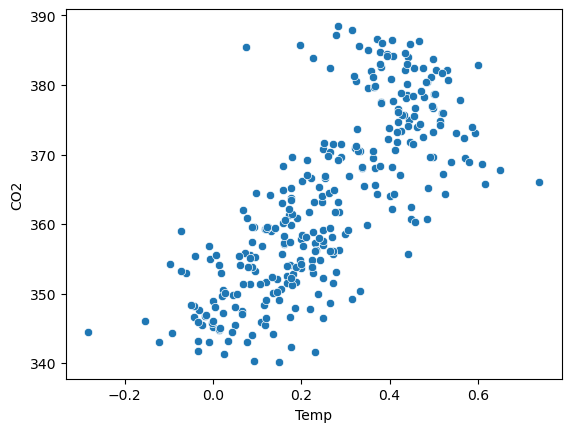

In [3]:
# Draw the scatter plot
sns.scatterplot(x="Temp",
                y="CO2",
                data=climate_df)

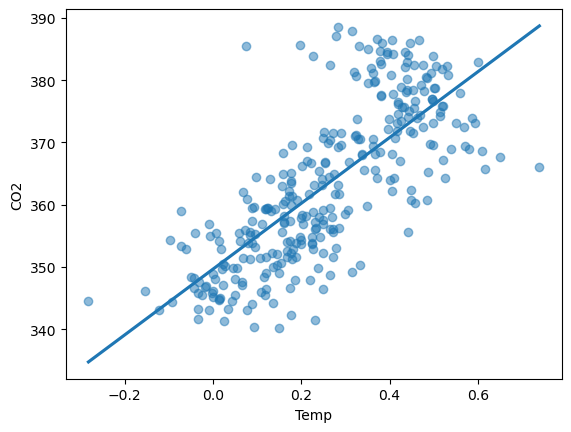

In [4]:
# Draw a trend line on the scatter plot of temp vs. co2
sns.regplot(x='Temp',
         y='CO2',
         data=climate_df,
         ci=None,
         scatter_kws={'alpha': 0.5})

# Show the plot
plt.show()

Linear regression models always fit a straight line to the data. Straight lines are defined by two properties: their intercept and their slope. The slope is the rate of change in the y direction divided by the rate of change in the x direction.

In [5]:
# Create the model object
mdl_temp_vs_co2 = ols('Temp ~ CO2', data=climate_df)

# Fit the model
mdl_temp_vs_co2 = mdl_temp_vs_co2.fit()

# Print the parameters of the fitted model
print(mdl_temp_vs_co2.params)

#Predicted Temp = -3.593140 + 0.010599 × CO2

Intercept   -3.593140
CO2          0.010599
dtype: float64


CO2 = 0.010599 — this is the slope: for every 1-unit increase in CO2, predicted temperature increases by about 0.0106 units. Since it's positive, it confirms the expected relationship: higher CO2 is associated with higher temperature. 
Intercept = -3.593140 — the predicted temperature when CO2 = 0.

With temperature as the response and CO2 as the predictor, the fitted line is temp = -3.593140 + 0.010599 × CO2, meaning each 1 ppm rise in atmospheric CO2 is associated with roughly a 0.0106°C increase in temperature — or about 1.06°C per 100 ppm — a small but physically sensible positive slope that lines up with the greenhouse-effect mechanism behind observed global warming trends; the intercept of -3.59°C is just the mathematical y-intercept (predicted temp when CO2 = 0) and isn't meaningful on its own, since CO2 has never been anywhere near zero in any observed record. 

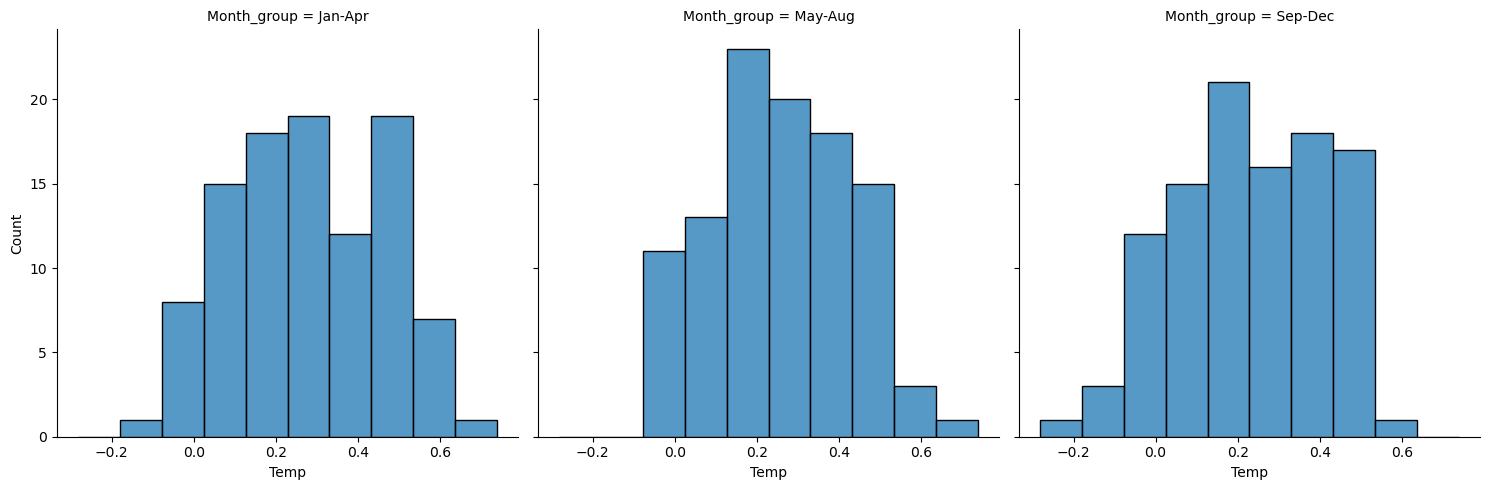

In [6]:
# Suppress benign FutureWarnings coming from seaborn's internal groupby calls
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
# Group months into 3 broader periods (adjust boundaries to your definition of seasons/periods)
climate_df['Month_group'] = pd.cut(climate_df['Month'],
                                    bins=[0, 4, 8, 12],
                                    labels=['Jan-Apr', 'May-Aug', 'Sep-Dec'])

# Histograms of Temp with 10 bins, split into 3 month groups
sns.displot(data=climate_df,
            x='Temp',
            col='Month_group',
            col_wrap=3, bins=10)
# Show the plot
plt.show()

In [7]:
# Calculate the mean of Temp, grouped by month group
mean_temp_by_month_group = climate_df.groupby('Month_group', observed=True)['Temp'].mean()
# Print the result
print(mean_temp_by_month_group)

Month_group
Jan-Apr    0.278450
May-Aug    0.259981
Sep-Dec    0.232731
Name: Temp, dtype: float64


In [8]:
# Create the model, fit it
mdl_temp_vs_month_group = ols('Temp ~ Month_group', data=climate_df).fit()
# Print the parameters of the fitted model
print(mdl_temp_vs_month_group.params)

Intercept                 0.278450
Month_group[T.May-Aug]   -0.018469
Month_group[T.Sep-Dec]   -0.045719
dtype: float64


In [9]:
# Create the model, fit it
mdl_temp_vs_month_group = ols('Temp ~ Month_group + 0', data=climate_df).fit()
# Print the parameters of the fitted model
print(mdl_temp_vs_month_group.params)

Month_group[Jan-Apr]    0.278450
Month_group[May-Aug]    0.259981
Month_group[Sep-Dec]    0.232731
dtype: float64


Regrouping our climate data into three 4-month periods (Jan-Apr, May-Aug, Sep-Dec) and comparing mean Temp across them that captures the seasonal cycle in temperature over the year. The intercept-included model (Temp ~ Month_group) expresses this as one reference period's mean plus offsets for the other two, while the no-intercept version (Temp ~ Month_group + 0) gives each period's raw mean directly — and by the same least-squares logic covered earlier, those coefficients are mathematically guaranteed to match mean_temp_by_month_group exactly, since OLS minimizes squared error independently within each non-overlapping group. 